#### Analyse, Visualisation et cartographie des Incidences de Pauvreté Réelle et Prédite par Région

- Ce script réalise une analyse approfondie et génère des visualisations des taux de pauvreté réels et prédits par région. Il est divisé en deux parties principales : le calcul des indicateurs et la création de graphiques comparatifs.

- Première partie : Calcul des incidences de pauvreté
Le script commence par charger un fichier CSV contenant des informations sur les ménages, y compris des variables comme hhweight (poids du ménage), hhsize (taille du ménage), et les indicateurs de pauvreté. Une fonction calcule l'incidence de la pauvreté réelle et prédite pour chaque région. Les incidences sont obtenues en pondérant les indicateurs de pauvreté par la taille et le poids des ménages, et sont exprimées en pourcentage, arrondies à une décimale. Ces résultats sont regroupés par région et sauvegardés dans un nouveau fichier CSV.

- Deuxième partie : Création et sauvegarde des graphiques
Dans cette étape, le script génère deux types de graphiques pour comparer les incidences de pauvreté réelle et prédite :

- Graphique linéaire : Affiche les tendances des deux indicateurs par région avec des lignes connectées par des points. Cela permet de visualiser facilement les écarts entre les deux séries pour chaque région.
- Graphique à barres : Montre une comparaison côte à côte des valeurs réelles et prédites pour chaque région, facilitant la perception des différences en termes de hauteur de barres.
Les graphiques sont sauvegardés dans un dossier dédié avec des noms explicites incluant le nom du fichier source pour une identification facile. Les fichiers graphiques sont sauvegardés en haute résolution (dpi=300) pour garantir une qualité optimale.
- Ce script permet de visualiser et de comparer les taux de pauvreté réelle et prédite pour chaque région de Côte d’Ivoire. Il exploite des données géospatiales (GeoJSON) décrivant les limites administratives des régions et des données tabulaires (CSV) contenant les incidences de pauvreté réelle et prédite. Le script réalise une série d'étapes comprenant la normalisation des noms des régions, la gestion des incohérences dans les correspondances grâce à des corrections manuelles et des correspondances approximatives, ainsi que la fusion des deux sources de données.

- Une fois les données fusionnées, des fourchettes de valeurs sont définies pour catégoriser les taux de pauvreté en groupes significatifs avec des couleurs distinctes. Le script génère ensuite des cartes annotées, où les noms des régions sont affichés au centre géométrique de chaque région. Il sauvegarde et affiche deux types de visualisations : des cartes individuelles pour les incidences de pauvreté réelle et prédite, et une vue côte à côte permettant une comparaison directe entre les deux. Le tout est enrichi d'une légende pour faciliter l’interprétation.

- En résumé, ce script offre une solution complète pour préparer, visualiser et comparer les données de pauvreté réelle et prédite en utilisant des techniques de géospatialisation et de cartographie

In [1]:
import pandas as pd

# Chemin d'accès au fichier CSV
file_path = r'D:\wealth_predict_2021\data\processed_csv\fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold_logistic_reg.csv'

# Charger les données
try:
    df = pd.read_csv(file_path)
    print("Fichier chargé avec succès.")
except FileNotFoundError:
    print(f"Le fichier est introuvable : {file_path}")
    exit()

# Fonction pour calculer les taux de pauvreté
def calculate_poverty_rate(group):
    total_weighted_population = (group['hhweight'] * group['hhsize']).sum()
    if total_weighted_population == 0:
        return pd.Series({'taux_pauvrete_reel': None, 'taux_pauvrete_prevu': None})
    real_poverty_rate = (group['hhweight'] * group['hhsize'] * group['pcexp_binaire']).sum() / total_weighted_population
    predicted_poverty_rate = (group['hhweight'] * group['hhsize'] * group['pcexp_binaire_pred']).sum() / total_weighted_population
    # Convertir les taux en pourcentage et arrondir à 1 chiffre après la virgule
    return pd.Series({
        'Incidence_pauvreté_réel_(%)': round(real_poverty_rate * 100, 1), 
        'Incidence_pauvreté_prédite_(%)': round(predicted_poverty_rate * 100, 1)
    })

# Calcul des taux par région
poverty_rates = df.groupby('region').apply(calculate_poverty_rate).reset_index()

# Chemin pour sauvegarder le fichier CSV
output_path = r'D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv'

# Sauvegarder les résultats
poverty_rates.to_csv(output_path, index=False)
print(f"Les taux de pauvreté par région ont été sauvegardés avec succès dans : {output_path}")


Fichier chargé avec succès.
Les taux de pauvreté par région ont été sauvegardés avec succès dans : D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv


In [ ]:
pd.read_csv(r'D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv')

Fichier chargé avec succès.


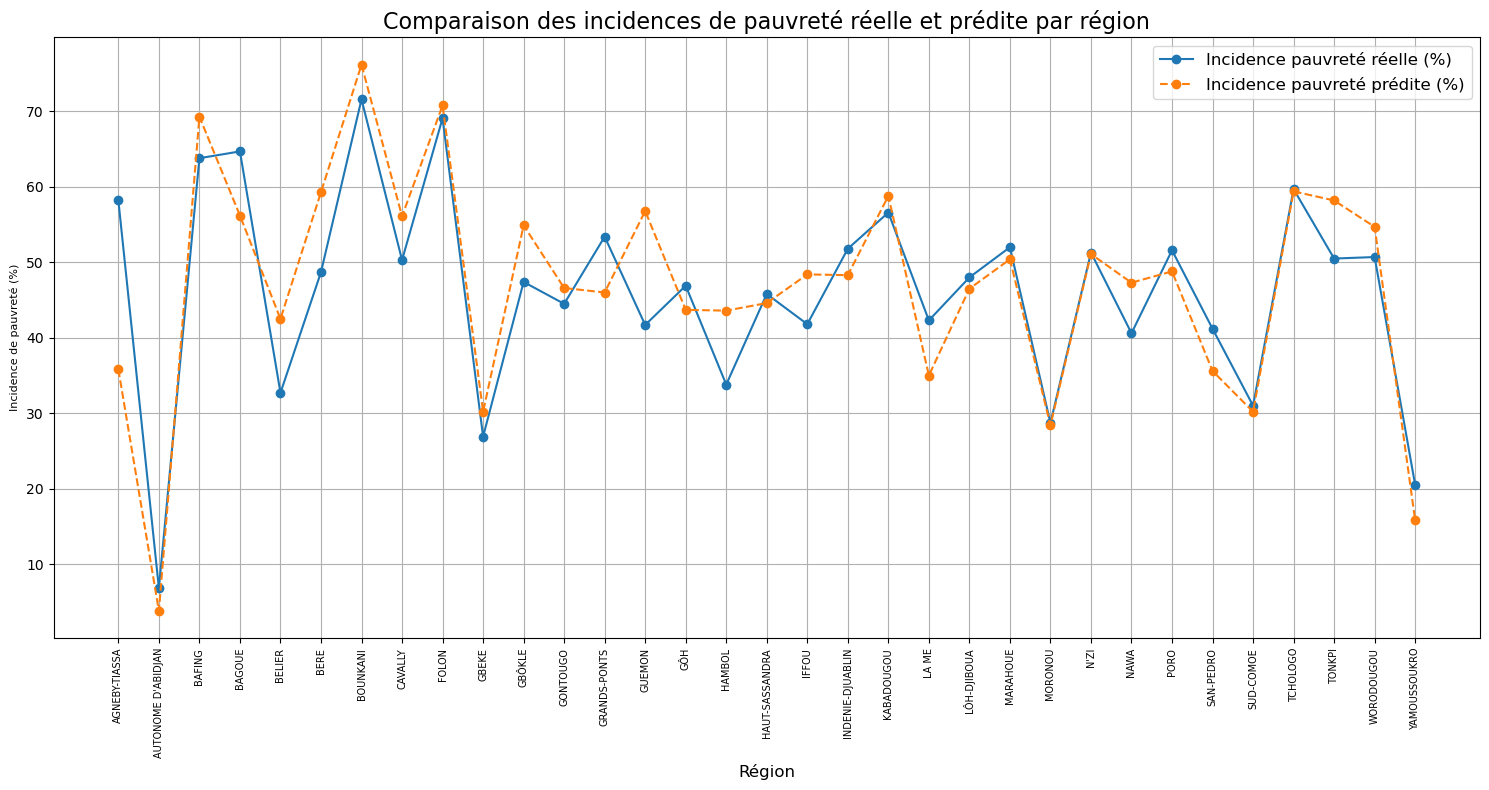

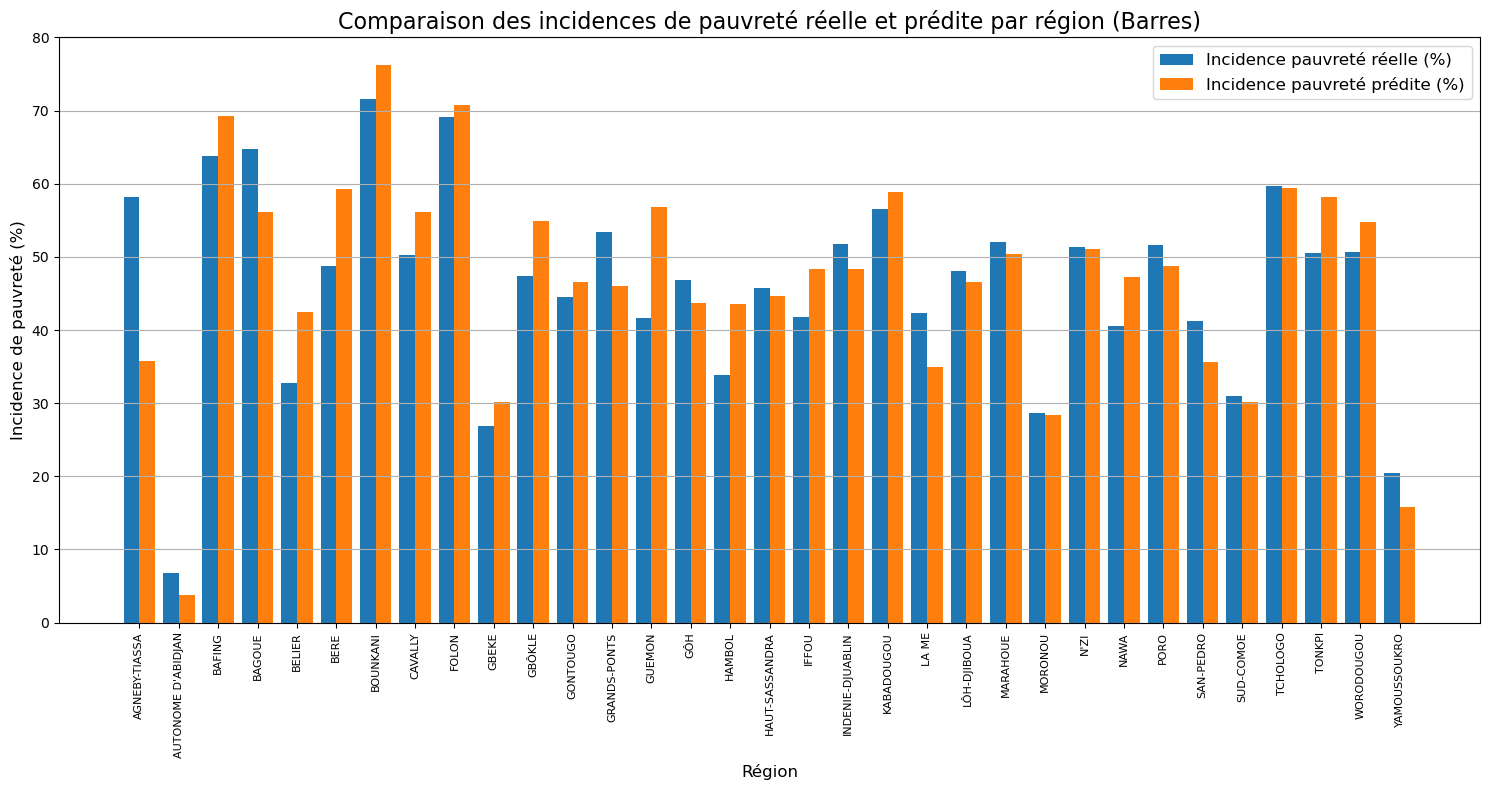

Graphiques sauvegardés :
- D:\wealth_predict_2021\figures_graphs\line_graph_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.png
- D:\wealth_predict_2021\figures_graphs\bar_graph_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.png


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Chemin d'accès au fichier CSV
file_path = r'D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv'

# Dossier pour sauvegarder les graphiques
output_dir = r'D:\wealth_predict_2021\figures_graphs'
os.makedirs(output_dir, exist_ok=True)  # Créer le dossier s'il n'existe pas

# Charger les données
try:
    poverty_rates = pd.read_csv(file_path)
    print("Fichier chargé avec succès.")
except FileNotFoundError:
    print(f"Le fichier est introuvable : {file_path}")
    exit()

# Variables pour les graphiques
regions = poverty_rates['region']
real_poverty = poverty_rates['Incidence_pauvreté_réel_(%)']
predicted_poverty = poverty_rates['Incidence_pauvreté_prédite_(%)']

# Graphique linéaire comparant les incidences
plt.figure(figsize=(15, 8))
plt.plot(regions, real_poverty, label="Incidence pauvreté réelle (%)", marker='o', linestyle='-')
plt.plot(regions, predicted_poverty, label="Incidence pauvreté prédite (%)", marker='o', linestyle='--')
plt.title("Comparaison des incidences de pauvreté réelle et prédite par région", fontsize=16)
plt.xlabel("Région", fontsize=12)
plt.ylabel("Incidence de pauvreté (%)", fontsize=8)
plt.xticks(rotation=90, fontsize=7)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
line_graph_path = os.path.join(output_dir, "line_graph_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.png")
plt.savefig(line_graph_path, dpi=300)
plt.show()

# Graphique à barres comparant les incidences
plt.figure(figsize=(15, 8))
width = 0.4
bar_positions = range(len(regions))

plt.bar([pos - width/2 for pos in bar_positions], real_poverty, width=width, label="Incidence pauvreté réelle (%)")
plt.bar([pos + width/2 for pos in bar_positions], predicted_poverty, width=width, label="Incidence pauvreté prédite (%)")

plt.title("Comparaison des incidences de pauvreté réelle et prédite par région (Barres)", fontsize=16)
plt.xlabel("Région", fontsize=12)
plt.ylabel("Incidence de pauvreté (%)", fontsize=12)
plt.xticks(bar_positions, regions, rotation=90, fontsize=8)
plt.legend(fontsize=12)
plt.grid(axis='y')
plt.tight_layout()
bar_graph_path = os.path.join(output_dir, "bar_graph_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.png")
plt.savefig(bar_graph_path, dpi=300)
plt.show()

print(f"Graphiques sauvegardés :\n- {line_graph_path}\n- {bar_graph_path}")


In [4]:
!pip install geopandas matplotlib pandas

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os
from difflib import get_close_matches

# Chemins des fichiers
geojson_path = r"D:\wealth_predict_2021\data\downloaded\gadm41_CIV_2.json\gadm41_CIV_2.json"
csv_file_path = r"D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv"
output_figure_path = r"D:\wealth_predict_2021\figures_graphs"

# Charger le GeoJSON
regions_map = gpd.read_file(geojson_path)

# Charger les données CSV
poverty_data = pd.read_csv(csv_file_path)

# Vérifier les colonnes disponibles
print("Colonnes du GeoJSON :", regions_map.columns)
print("Colonnes du CSV :", poverty_data.columns)

# Prétraitement des noms de régions
# Normaliser les noms des régions (exemple : suppression des espaces, conversion en minuscules)
regions_map['region_name'] = regions_map['NAME_1'].str.strip().str.lower()
poverty_data['region_name'] = poverty_data['region'].str.strip().str.lower()

# Gérer les correspondances approximatives
def match_names(name, reference_list):
    matches = get_close_matches(name, reference_list, n=1, cutoff=0.8)  # Ajustez le cutoff si nécessaire
    return matches[0] if matches else None

# Créer une correspondance flexible
poverty_data['region_name_matched'] = poverty_data['region_name'].apply(
    lambda x: match_names(x, regions_map['region_name'].tolist())
)

# Fusionner les données
regions_map = regions_map.merge(
    poverty_data,
    left_on="region_name",
    right_on="region_name_matched"
)

# Définir les fourchettes et les labels
bins = [0, 33.1, 46.3, 56.4, 67.7]
labels = ['0 - 33.1', '33.2 - 46.3', '46.4 - 56.4', '56.5 - 67.7']

# Ajouter des groupes de pauvreté réelle
regions_map['group_real'] = pd.cut(
    regions_map['Incidence_pauvreté_réel_(%)'], bins=bins, labels=labels
)

# Ajouter des groupes de pauvreté prédite
regions_map['group_predicted'] = pd.cut(
    regions_map['Incidence_pauvreté_prédite_(%)'], bins=bins, labels=labels
)

# Fonction pour créer et sauvegarder les cartes
def create_map(column, title, filename):
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    regions_map.plot(
        column=column,
        cmap='OrRd',
        linewidth=0.8,
        ax=ax,
        edgecolor='0.8',
        legend=True
    )
    ax.set_title(title, fontsize=16)
    ax.axis('off')
    
    # Sauvegarder la carte
    output_path = os.path.join(output_figure_path, filename)
    plt.savefig(output_path, dpi=300)
    plt.close(fig)

# Carte de la pauvreté réelle
create_map(
    column='group_real',
    title="Incidence de la pauvreté réelle par région, Côte d'Ivoire",
    filename="poverty_real_fullyConv_sans_augm_couche_nongelee_batch_16.png"
)

# Carte de la pauvreté prédite
create_map(
    column='group_predicted',
    title="Incidence de la pauvreté prédite par région, Côte d'Ivoire",
    filename="poverty_predicted_fullyConv_sans_augm_couche_nongelee_batch_16.png"
)

print("Cartes générées et sauvegardées avec succès.")


In [ ]:
print(poverty_data[poverty_data['region_name_matched'].isnull()])


In [ ]:
import geopandas as gpd

# Chemin du fichier JSON
geojson_path = r"D:\wealth_predict_2021\data\downloaded\gadm41_CIV_2.json\gadm41_CIV_2.json"

# Charger le fichier JSON
regions_map = gpd.read_file(geojson_path)

# Afficher les colonnes disponibles
print("Colonnes disponibles dans le fichier GeoJSON :")
print(regions_map.columns)

# Aperçu des données
print("Aperçu des 5 premières lignes :")
print(regions_map.head())


In [ ]:
# Afficher les noms uniques des régions de premier niveau
print("Noms uniques des régions (NAME_1) :")
print(regions_map['NAME_1'].unique())

# Afficher les noms uniques des subdivisions de niveau 2
print("\nNoms uniques des subdivisions (NAME_2) :")
print(regions_map['NAME_2'].unique())


In [ ]:
import geopandas as gpd
import pandas as pd
from difflib import get_close_matches

# Chemins des fichiers
geojson_path = r"D:\wealth_predict_2021\data\downloaded\gadm41_CIV_2.json\gadm41_CIV_2.json"
csv_file_path = r"D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv"

# Charger les données
regions_map = gpd.read_file(geojson_path)
poverty_data = pd.read_csv(csv_file_path)

# Normaliser les noms
regions_map['normalized_name'] = regions_map['NAME_2'].str.lower().str.replace(r"[^a-z]", "", regex=True)
poverty_data['normalized_region'] = poverty_data['region'].str.lower().str.replace(r"[^a-z]", "", regex=True)

# Dictionnaire de corrections manuelles
manual_mapping = {
    'autonomedeabidjan': 'abidjan',
    'sudcomoe': 'sudcomoé',
    'grandsponts': 'grands-ponts'
}

# Appliquer les corrections manuelles
poverty_data['normalized_region'] = poverty_data['normalized_region'].replace(manual_mapping)

# Correspondance approximative
def match_names(name, reference_list):
    matches = get_close_matches(name, reference_list, n=1, cutoff=0.8)
    return matches[0] if matches else None

poverty_data['matched_region'] = poverty_data['normalized_region'].apply(
    lambda x: match_names(x, regions_map['normalized_name'].tolist())
)

# Vérifier les noms non appariés
non_matched = poverty_data[poverty_data['matched_region'].isnull()]
print("Noms non appariés :", non_matched['region'])

# Fusionner les données
regions_map = regions_map.merge(
    poverty_data,
    left_on="normalized_name",
    right_on="matched_region"
)

# Afficher un aperçu des données fusionnées
print(regions_map)


##### Cartographie de l'Incidence de la Pauvreté Réelle et Prédite en Côte d'Ivoire

Ce script permet de visualiser et de comparer les taux de pauvreté réelle et prédite pour chaque région de Côte d’Ivoire. Il exploite des données géospatiales (GeoJSON) décrivant les limites administratives des régions et des données tabulaires (CSV) contenant les incidences de pauvreté réelle et prédite. Le script réalise une série d'étapes comprenant la normalisation des noms des régions, la gestion des incohérences dans les correspondances grâce à des corrections manuelles et des correspondances approximatives, ainsi que la fusion des deux sources de données.

Une fois les données fusionnées, des fourchettes de valeurs sont définies pour catégoriser les taux de pauvreté en groupes significatifs avec des couleurs distinctes. Le script génère ensuite des cartes annotées, où les noms des régions sont affichés au centre géométrique de chaque région. Il sauvegarde et affiche deux types de visualisations : des cartes individuelles pour les incidences de pauvreté réelle et prédite, et une vue côte à côte permettant une comparaison directe entre les deux. Le tout est enrichi d'une légende pour faciliter l’interprétation.

En résumé, ce script offre une solution complète pour préparer, visualiser et comparer les données de pauvreté réelle et prédite en utilisant des techniques de géospatialisation et de cartographie

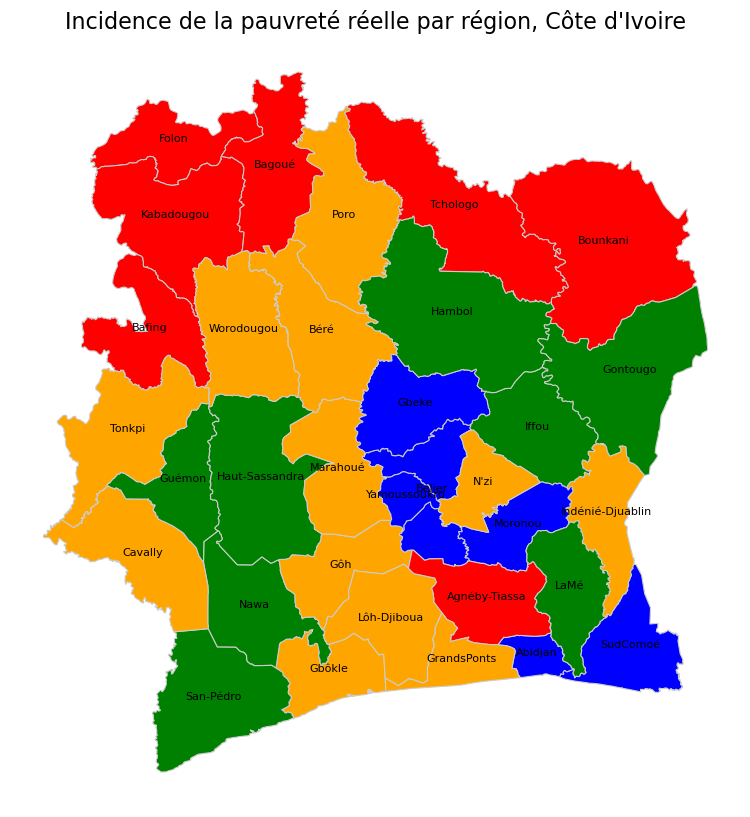

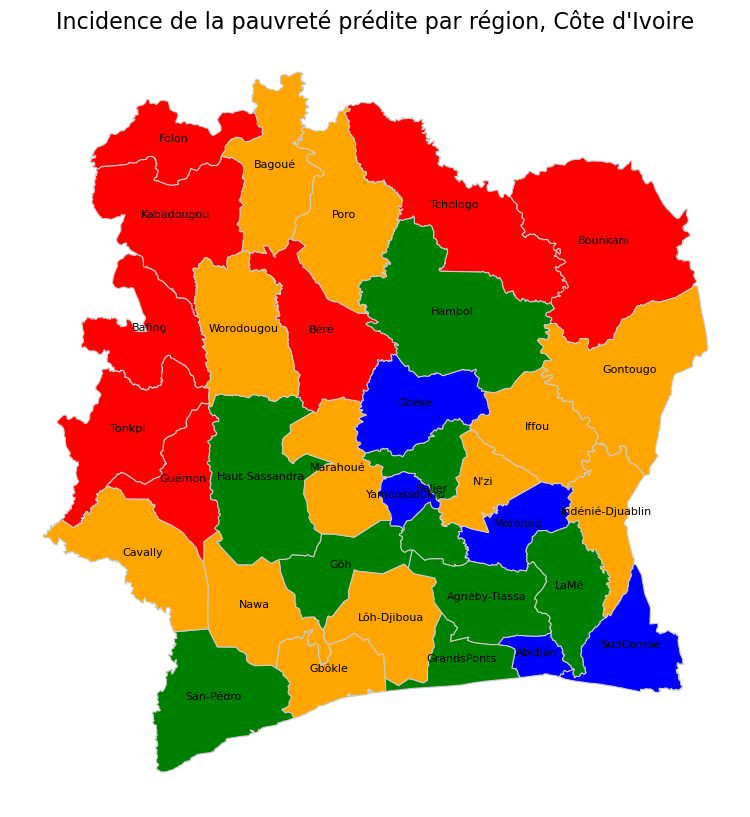

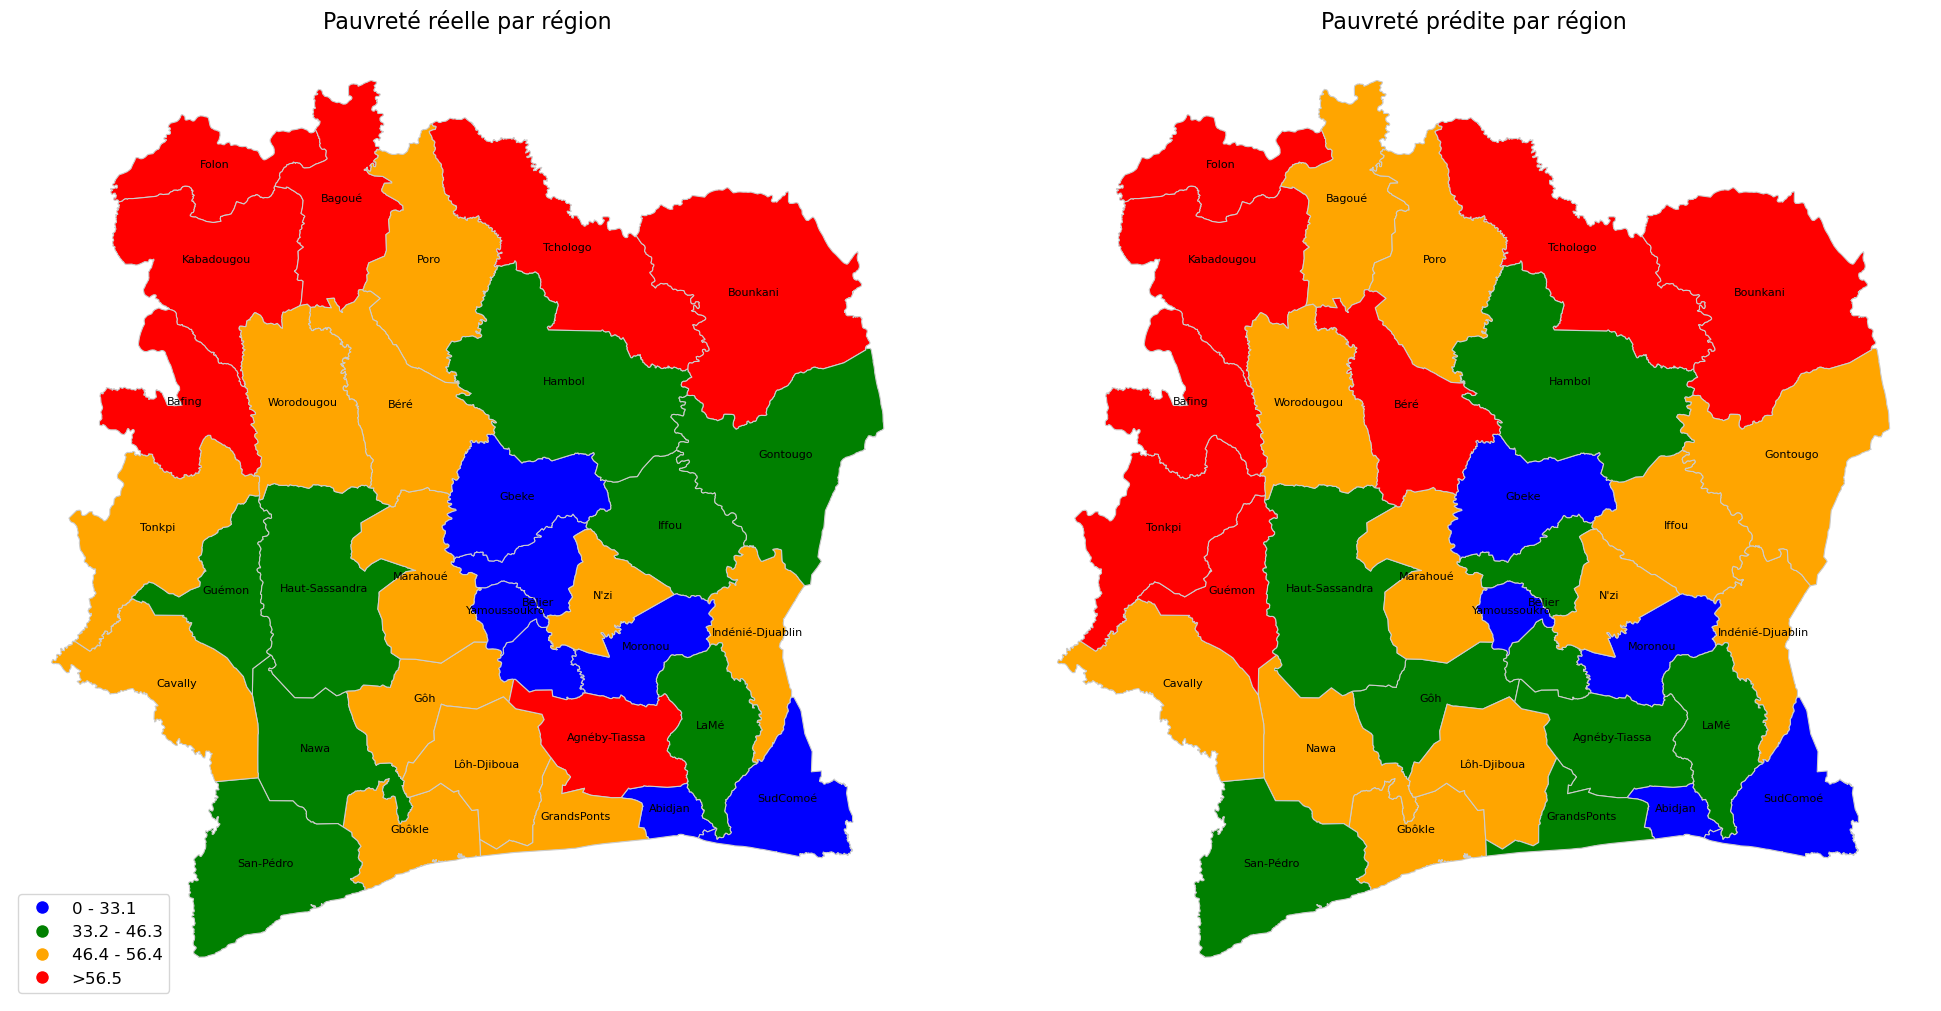

In [10]:
import geopandas as gpd  # Pour travailler avec des données géospatiales
import pandas as pd  # Pour manipuler les données tabulaires
import matplotlib.pyplot as plt  # Pour créer des visualisations
import os  # Pour manipuler les chemins de fichiers
from difflib import get_close_matches  # Pour effectuer des correspondances approximatives entre chaînes

# Chemins des fichiers nécessaires
geojson_path = r"D:\wealth_predict_2021\data\downloaded\gadm41_CIV_2.json\gadm41_CIV_2.json"  # Chemin vers le fichier GeoJSON
csv_file_path = r"D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv"  # Chemin vers le fichier CSV
output_figure_path = r"D:\wealth_predict_2021\figures_graphs"  # Répertoire où sauvegarder les figures

# Charger les données géospatiales depuis le fichier GeoJSON
regions_map = gpd.read_file(geojson_path)

# Charger les données de pauvreté depuis le fichier CSV
poverty_data = pd.read_csv(csv_file_path)

# **Étape 1 : Normalisation des noms pour une correspondance cohérente**
# Supprimer les espaces, caractères spéciaux, et mettre les noms en minuscules
regions_map['normalized_name'] = regions_map['NAME_2'].str.lower().str.replace(r"[^a-z]", "", regex=True)
poverty_data['normalized_region'] = poverty_data['region'].str.lower().str.replace(r"[^a-z]", "", regex=True)

# **Étape 2 : Ajout de corrections manuelles pour traiter les cas spécifiques**
# Certains noms dans le CSV et le GeoJSON ne correspondent pas directement, nous les corrigeons ici
manual_mapping = {
    'autonomedabidjan': 'abidjan',
    'sudcomoe': 'sudcomoé',
    'bere': 'br'  # Correction pour "BERE" qui est écrit "br" dans le GeoJSON
}
poverty_data['normalized_region'] = poverty_data['normalized_region'].replace(manual_mapping)

# **Étape 3 : Correspondance approximative**
# Fonction pour trouver la correspondance la plus proche entre deux listes
def match_names(name, reference_list):
    matches = get_close_matches(name, reference_list, n=1, cutoff=0.8)
    return matches[0] if matches else None

# Appliquer la correspondance approximative
poverty_data['matched_region'] = poverty_data['normalized_region'].apply(
    lambda x: match_names(x, regions_map['normalized_name'].tolist())
)

# **Étape 4 : Gestion des correspondances manuelles**
# Forcer les corrections pour les cas non appariés
poverty_data.loc[poverty_data['region'] == 'BERE', 'matched_region'] = 'br'

# **Étape 5 : Fusionner les données**
# Joindre les données géospatiales avec les données de pauvreté
regions_map = regions_map.merge(
    poverty_data,
    left_on="normalized_name",  # Colonne normalisée dans le GeoJSON
    right_on="matched_region"  # Colonne correspondante dans le CSV
)

# **Étape 6 : Définir les fourchettes et attribuer les groupes**
bins = [0, 33.1, 46.3, 56.4, 100]  # Définir les limites des catégories
labels = ['0 - 33.1', '33.2 - 46.3', '46.4 - 56.4', '>56.5']  # Étiquettes des catégories

# Ajouter des groupes de pauvreté réelle
regions_map['group_real'] = pd.cut(
    regions_map['Incidence_pauvreté_réel_(%)'], bins=bins, labels=labels
)

# Ajouter des groupes de pauvreté prédite
regions_map['group_predicted'] = pd.cut(
    regions_map['Incidence_pauvreté_prédite_(%)'], bins=bins, labels=labels
)

# **Étape 7 : Définir les couleurs pour chaque groupe**
color_map = {
    '0 - 33.1': 'blue',
    '33.2 - 46.3': 'green',
    '46.4 - 56.4': 'orange',
    '>56.5': 'red'
}

# **Étape 8 : Fonction pour créer des cartes avec annotations**
def create_map_with_labels(ax, column, title):
    # Attribuer les couleurs selon les groupes
    regions_map['color'] = regions_map[column].map(color_map)
    regions_map.plot(
        color=regions_map['color'],  # Utiliser les couleurs définies
        linewidth=0.8,
        ax=ax,
        edgecolor='0.8'
    )
    # Annoter les noms des régions au centroïde
    for _, row in regions_map.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(
            text=row['NAME_2'],  # Nom de la région
            xy=(centroid.x, centroid.y),  # Coordonnées du centroïde
            ha='center',
            fontsize=8,
            color='black'
        )
    ax.set_title(title, fontsize=16)
    ax.axis('off')

# **Étape 9 : Afficher et sauvegarder les cartes individuelles**
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
create_map_with_labels(ax, 'group_real', "Incidence de la pauvreté réelle par région, Côte d'Ivoire")
plt.savefig(os.path.join(output_figure_path, "poverty_real_with_labels.png"))
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
create_map_with_labels(ax, 'group_predicted', "Incidence de la pauvreté prédite par région, Côte d'Ivoire")
plt.savefig(os.path.join(output_figure_path, "poverty_predicted_with_labels.png"))
plt.show()

# **Étape 10 : Afficher et sauvegarder les cartes côte à côte**
fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)
create_map_with_labels(axes[0], 'group_real', "Pauvreté réelle par région")
create_map_with_labels(axes[1], 'group_predicted', "Pauvreté prédite par région")

# Ajouter une légende manuelle
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=color, markersize=10)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, loc='lower left', fontsize=12)

# Sauvegarder et afficher les cartes côte à côte
plt.savefig(os.path.join(output_figure_path, "poverty_real_vs_predicted_side_by_side.png"))
plt.show()


#### Carte interactive des indices de pauvreté régionaux

- Ce script combine des données géospatiales de la Côte d’Ivoire, provenant d’un fichier GeoJSON, avec des données tabulaires de pauvreté réelle et prédite issues d’un fichier CSV. Après avoir harmonisé les noms des régions via des normalisations et des corrections manuelles, il fusionne les deux ensembles de données pour produire une carte interactive.
- Chaque région est colorée en fonction de son taux de pauvreté réelle, classé dans des catégories définies (0 - 33.1, 33.2 - 46.3, 46.4 - 56.4, et >56.5) et associée à une couleur spécifique (blue, green, orange, red). Les valeurs manquantes sont remplies par défaut avec 0 pour éviter les incohérences.
- Le script génère une carte interactive avec des couches enrichies par des popups dynamiques affichant les informations de pauvreté réelle et prédite pour chaque région. Une légende statique présente les catégories de couleur directement sur la carte.

Objectifs principaux :
1. Normalisation et fusion des données :

Harmoniser les noms des régions pour établir des correspondances précises entre le GeoJSON et le CSV.
Fusionner les données géospatiales et tabulaires pour obtenir un GeoDataFrame complet.
2. Classification et visualisation :

Classifier les taux de pauvreté réelle en groupes spécifiques et attribuer des couleurs adaptées.
Générer une carte interactive avec des régions colorées selon leur taux de pauvreté.
3. Popups et légende :

Ajouter des popups dynamiques affichant les informations sur les taux de pauvreté.
Créer une légende statique pour interpréter les couleurs des catégories.
4. Sauvegarde des résultats :

Enregistrer les données fusionnées en GeoJSON pour une réutilisation future.
Sauvegarder la carte interactive en HTML pour une exploration via un navigateur.
5. Résultats :
Fichier GeoJSON fusionné : poverty_map_1_fullyConv_sans_augm_couche_nongelee_batch_16.geojson
Carte interactive HTML : poverty_map_1_fullyConv_sans_augm_couche_nongelee_batch_16.html
La carte finale permet d'explorer visuellement les indices de pauvreté régionaux avec des informations détaillées et une navigation interactive.

In [11]:
import geopandas as gpd
import pandas as pd
import folium
import os
from branca.element import Template, MacroElement

# Chemins des fichiers nécessaires
geojson_path = r"D:\wealth_predict_2021\data\downloaded\gadm41_CIV_2.json\gadm41_CIV_2.json"
csv_file_path = r"D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv"

# Définir les chemins de sortie
output_directory = r"D:\wealth_predict_2021\data\html_output"
output_geojson_path = os.path.join(output_directory, "poverty_map_1_fullyConv_sans_augm_couche_nongelee_batch_16.geojson")
output_html_path = os.path.join(output_directory, "poverty_map_1_fullyConv_sans_augm_couche_nongelee_batch_16.html")

# Vérification et création des répertoires nécessaires
if not os.path.exists(output_directory):
    os.makedirs(output_directory)
    print(f"Répertoire créé : {output_directory}")

# Charger les données géospatiales depuis le fichier GeoJSON
regions_map = gpd.read_file(geojson_path)

# Charger les données de pauvreté depuis le fichier CSV
poverty_data = pd.read_csv(csv_file_path)

# **Étape 1 : Normalisation des noms pour correspondance**
regions_map['normalized_name'] = regions_map['NAME_2'].str.lower().str.replace(r"[^a-z]", "", regex=True)
poverty_data['normalized_region'] = poverty_data['region'].str.lower().str.replace(r"[^a-z]", "", regex=True)

# **Étape 2 : Correction des noms manuels**
manual_mapping = {
    'autonomedabidjan': 'abidjan',
    'sudcomoe': 'sudcomo',
    'bere': 'br',
    'agnebytiassa': 'agnbytiassa',
    'bagoue': 'bagou',
    'belier': 'blier',
    'guemon': 'gumon',
    'indeniedjuablin': 'indnidjuablin',
    'lame': 'lam',
    'marahoue': 'marahou',
    'sanpedro': 'sanpdro'
}
poverty_data['normalized_region'] = poverty_data['normalized_region'].replace(manual_mapping)

# **Étape 3 : Vérification des correspondances**
missing_in_csv = regions_map[~regions_map['normalized_name'].isin(poverty_data['normalized_region'])]
print("Régions dans le GeoJSON mais absentes dans le CSV après correction finale :")
print(missing_in_csv[['NAME_2', 'normalized_name']])

missing_in_geojson = poverty_data[~poverty_data['normalized_region'].isin(regions_map['normalized_name'])]
print("Régions dans le CSV mais absentes dans le GeoJSON après correction finale :")
print(missing_in_geojson[['region', 'normalized_region']])

# **Étape 4 : Fusion des données**
regions_map = regions_map.merge(
    poverty_data,
    left_on="normalized_name",
    right_on="normalized_region",
    how="left"
)

# Ajouter des valeurs par défaut pour les régions manquantes
regions_map['Incidence_pauvreté_réel_(%)'] = regions_map['Incidence_pauvreté_réel_(%)'].fillna(0)
regions_map['Incidence_pauvreté_prédite_(%)'] = regions_map['Incidence_pauvreté_prédite_(%)'].fillna(0)

# **Étape 5 : Sauvegarde en GeoJSON**
regions_map.to_file(output_geojson_path, driver="GeoJSON")
print(f"Fichier GeoJSON sauvegardé à : {output_geojson_path}")

# **Étape 6 : Définir les couleurs personnalisées**
color_map = {
    '0 - 33.1': 'blue',
    '33.2 - 46.3': 'green',
    '46.4 - 56.4': 'orange',
    '>56.5': 'red'
}

# Catégoriser les valeurs de pauvreté
def categorize_poverty(value):
    if value <= 33.1:
        return '0 - 33.1'
    elif 33.1 < value <= 46.3:
        return '33.2 - 46.3'
    elif 46.3 < value <= 56.4:
        return '46.4 - 56.4'
    else:
        return '>56.5'

regions_map['poverty_category'] = regions_map['Incidence_pauvreté_réel_(%)'].apply(categorize_poverty)
regions_map['color'] = regions_map['poverty_category'].map(color_map)

# **Étape 7 : Créer une carte interactive avec Folium**
map_civ = folium.Map(location=[7.539989, -5.54708], zoom_start=6)

# Ajouter les régions avec des couleurs personnalisées
for _, row in regions_map.iterrows():
    folium.GeoJson(
        row.geometry,
        style_function=lambda feature, color=row['color']: {
            'fillColor': color,
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        }
    ).add_to(map_civ)

# Ajouter des popups dynamiques pour chaque région
for _, row in regions_map.iterrows():
    popup_info = f"<b>{row['NAME_2']}</b><br>Pauvreté réelle : {row['Incidence_pauvreté_réel_(%)']}%<br>Pauvreté prédite : {row['Incidence_pauvreté_prédite_(%)']}%"
    folium.Marker(
        location=[row.geometry.centroid.y, row.geometry.centroid.x],
        popup=popup_info
    ).add_to(map_civ)

# Ajouter une légende manuelle
legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 200px;
    height: 150px;
    background-color: white;
    z-index: 1000;
    border:2px solid grey;
    padding: 10px;
">
    <h4>Catégories de pauvreté</h4>
    <i style="background:blue;width:10px;height:10px;float:left;margin-right:10px;"></i> 0 - 33.1<br>
    <i style="background:green;width:10px;height:10px;float:left;margin-right:10px;"></i> 33.2 - 46.3<br>
    <i style="background:orange;width:10px;height:10px;float:left;margin-right:10px;"></i> 46.4 - 56.4<br>
    <i style="background:red;width:10px;height:10px;float:left;margin-right:10px;"></i> > 56.5<br>
</div>
"""

macro = MacroElement()
macro._template = Template(legend_html)
map_civ.get_root().add_child(macro)

# **Étape 8 : Sauvegarder la carte HTML**
map_civ.save(output_html_path)
print(f"Carte interactive sauvegardée à : {output_html_path}")


Régions dans le GeoJSON mais absentes dans le CSV après correction finale :
Empty DataFrame
Columns: [NAME_2, normalized_name]
Index: []
Régions dans le CSV mais absentes dans le GeoJSON après correction finale :
Empty DataFrame
Columns: [region, normalized_region]
Index: []
Fichier GeoJSON sauvegardé à : D:\wealth_predict_2021\data\html_output\poverty_map_1_fullyConv_sans_augm_couche_nongelee_batch_16.geojson
Carte interactive sauvegardée à : D:\wealth_predict_2021\data\html_output\poverty_map_1_fullyConv_sans_augm_couche_nongelee_batch_16.html


##### Carte interactive avec couches de pauvreté réelle et prédite pour la Côte d'Ivoire

Ce script génère une carte interactive qui visualise les taux de pauvreté réelle et prédite des régions de la Côte d'Ivoire, basés sur des données géospatiales et statistiques. Le script fonctionne en plusieurs étapes :

1. Chargement des données géospatiales et tabulaires : Les informations géographiques des régions (GeoJSON) et les données tabulaires de pauvreté (CSV) sont importées.

2. Normalisation des noms : Les noms des régions dans les deux fichiers sont harmonisés via la suppression des caractères spéciaux et la mise en minuscules. Une correction manuelle est appliquée pour résoudre les incohérences.

3. Fusion des données : Les données de pauvreté sont fusionnées avec les données géospatiales en fonction des noms normalisés des régions. Les valeurs manquantes sont remplies par défaut avec 0.

4. Classification des taux de pauvreté : Les taux de pauvreté réelle et prédite sont classés en catégories définies (0 - 33.1, 33.2 - 46.3, 46.4 - 56.4, >56.5), avec des couleurs spécifiques associées à chaque catégorie.

5. Création de la carte interactive : Une carte interactive est construite avec deux couches :

- Une couche représentant les taux de pauvreté réelle.
- Une autre pour les taux de pauvreté prédite. Les utilisateurs peuvent basculer entre ces couches grâce à un contrôle interactif.
- Popups et légende : Des popups dynamiques affichent les taux de pauvreté pour chaque région. Une légende statique permet d'interpréter les couleurs des catégories directement sur la carte.

6. Sauvegarde des résultats :

Les données fusionnées sont enregistrées sous forme de fichier GeoJSON.
La carte interactive est sauvegardée au format HTML.

7. Résultats générés :
Fichier GeoJSON :
poverty_map_2_fullyConv_sans_augm_couche_nongelee_batch_16.geojson
Contient les données géographiques et statistiques fusionnées.

8. Carte interactive HTML :
poverty_map_2_fullyConv_sans_augm_couche_nongelee_batch_16.html
Permet une navigation interactive pour explorer les données de pauvreté.

9. Utilisation :
Le script est conçu pour permettre l'exploration visuelle des données de pauvreté en Côte d'Ivoire, avec la possibilité de comparer les valeurs réelles et prédites directement sur une carte interactive.

In [12]:
import geopandas as gpd
import pandas as pd
import folium
import os
from branca.element import Template, MacroElement

# **Étape 1 : Chemins des fichiers**
geojson_path = r"D:\wealth_predict_2021\data\downloaded\gadm41_CIV_2.json\gadm41_CIV_2.json"
csv_file_path = r"D:\wealth_predict_2021\data\processed_csv\poverty_rates_by_region_fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_5-fold.csv"
output_directory = r"D:\wealth_predict_2021\data\html_output"

# Nom commun pour les fichiers de sortie
file_suffix = "fullyConv_sans_augm_couche_nongelee_batch_16"
output_geojson_path = os.path.join(output_directory, f"poverty_map_2_{file_suffix}.geojson")
output_html_path = os.path.join(output_directory, f"poverty_map_2_{file_suffix}.html")

# Vérification des répertoires
if not os.path.exists(output_directory):
    os.makedirs(output_directory)
    print(f"Répertoire créé : {output_directory}")

# **Étape 2 : Charger les données**
regions_map = gpd.read_file(geojson_path)
poverty_data = pd.read_csv(csv_file_path)

# **Étape 3 : Normalisation des noms**
regions_map['normalized_name'] = regions_map['NAME_2'].str.lower().str.replace(r"[^a-z]", "", regex=True)
poverty_data['normalized_region'] = poverty_data['region'].str.lower().str.replace(r"[^a-z]", "", regex=True)

# **Étape 4 : Correction des noms manuels**
manual_mapping = {
    'autonomedabidjan': 'abidjan',
    'sudcomoe': 'sudcomo',
    'bere': 'br',
    'agnebytiassa': 'agnbytiassa',
    'bagoue': 'bagou',
    'belier': 'blier',
    'guemon': 'gumon',
    'indeniedjuablin': 'indnidjuablin',
    'lame': 'lam',
    'marahoue': 'marahou',
    'sanpedro': 'sanpdro'
}
poverty_data['normalized_region'] = poverty_data['normalized_region'].replace(manual_mapping)

# Vérification des correspondances après corrections
missing_in_csv = regions_map[~regions_map['normalized_name'].isin(poverty_data['normalized_region'])]
print("Régions dans le GeoJSON mais absentes dans le CSV après correction finale :")
print(missing_in_csv[['NAME_2', 'normalized_name']])

missing_in_geojson = poverty_data[~poverty_data['normalized_region'].isin(regions_map['normalized_name'])]
print("Régions dans le CSV mais absentes dans le GeoJSON après correction finale :")
print(missing_in_geojson[['region', 'normalized_region']])

# **Étape 5 : Fusionner les données**
regions_map = regions_map.merge(
    poverty_data,
    left_on="normalized_name",
    right_on="normalized_region",
    how="left"
)

# Remplir les valeurs manquantes par défaut
regions_map['Incidence_pauvreté_réel_(%)'] = regions_map['Incidence_pauvreté_réel_(%)'].fillna(0)
regions_map['Incidence_pauvreté_prédite_(%)'] = regions_map['Incidence_pauvreté_prédite_(%)'].fillna(0)

# Sauvegarder le GeoJSON fusionné
regions_map.to_file(output_geojson_path, driver="GeoJSON")
print(f"Fichier GeoJSON sauvegardé à : {output_geojson_path}")

# **Étape 6 : Définir les couleurs des catégories**
color_map = {
    '0 - 33.1': 'blue',
    '33.2 - 46.3': 'green',
    '46.4 - 56.4': 'orange',
    '>56.5': 'red'
}

def categorize_poverty(value):
    if value <= 33.1:
        return '0 - 33.1'
    elif 33.1 < value <= 46.3:
        return '33.2 - 46.3'
    elif 46.3 < value <= 56.4:
        return '46.4 - 56.4'
    else:
        return '>56.5'

regions_map['real_category'] = regions_map['Incidence_pauvreté_réel_(%)'].apply(categorize_poverty)
regions_map['predicted_category'] = regions_map['Incidence_pauvreté_prédite_(%)'].apply(categorize_poverty)
regions_map['real_color'] = regions_map['real_category'].map(color_map)
regions_map['predicted_color'] = regions_map['predicted_category'].map(color_map)

# **Étape 7 : Créer la carte interactive avec deux couches**
map_civ = folium.Map(location=[7.539989, -5.54708], zoom_start=6)

# Couche des valeurs réelles
real_layer = folium.FeatureGroup(name="Pauvreté réelle", show=True)
for _, row in regions_map.iterrows():
    folium.GeoJson(
        row.geometry,
        style_function=lambda feature, color=row['real_color']: {
            'fillColor': color,
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        },
        tooltip=folium.Tooltip(
            f"<b>{row['NAME_2']}</b><br>Pauvreté réelle : {row['Incidence_pauvreté_réel_(%)']}%"
        )
    ).add_to(real_layer)
real_layer.add_to(map_civ)

# Couche des valeurs prédites
predicted_layer = folium.FeatureGroup(name="Pauvreté prédite", show=False)
for _, row in regions_map.iterrows():
    folium.GeoJson(
        row.geometry,
        style_function=lambda feature, color=row['predicted_color']: {
            'fillColor': color,
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        },
        tooltip=folium.Tooltip(
            f"<b>{row['NAME_2']}</b><br>Pauvreté prédite : {row['Incidence_pauvreté_prédite_(%)']}%"
        )
    ).add_to(predicted_layer)
predicted_layer.add_to(map_civ)

# Ajouter un contrôle pour basculer entre les couches
folium.LayerControl(collapsed=False).add_to(map_civ)

# Ajouter une légende personnalisée
legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 200px;
    height: 150px;
    background-color: white;
    z-index: 1000;
    border:2px solid grey;
    padding: 10px;
">
    <h4>Catégories de pauvreté</h4>
    <i style="background:blue;width:10px;height:10px;float:left;margin-right:10px;"></i> 0 - 33.1<br>
    <i style="background:green;width:10px;height:10px;float:left;margin-right:10px;"></i> 33.2 - 46.3<br>
    <i style="background:orange;width:10px;height:10px;float:left;margin-right:10px;"></i> 46.4 - 56.4<br>
    <i style="background:red;width:10px;height:10px;float:left;margin-right:10px;"></i> >56.5<br>
</div>
"""
macro = MacroElement()
macro._template = Template(legend_html)
map_civ.get_root().add_child(macro)

# **Étape 8 : Sauvegarder la carte HTML**
map_civ.save(output_html_path)
print(f"Carte interactive sauvegardée à : {output_html_path}")


Régions dans le GeoJSON mais absentes dans le CSV après correction finale :
Empty DataFrame
Columns: [NAME_2, normalized_name]
Index: []
Régions dans le CSV mais absentes dans le GeoJSON après correction finale :
Empty DataFrame
Columns: [region, normalized_region]
Index: []
Fichier GeoJSON sauvegardé à : D:\wealth_predict_2021\data\html_output\poverty_map_2_fullyConv_sans_augm_couche_nongelee_batch_16.geojson
Carte interactive sauvegardée à : D:\wealth_predict_2021\data\html_output\poverty_map_2_fullyConv_sans_augm_couche_nongelee_batch_16.html
